# Bonus Analysis

### Analyst:
Eyerusalem Debero

### Data
05/29/2026

### Territory Manager:
Erbayne Middleton

This notebook includes additional bonus analysis questions using Python, pandas, NumPy, and Matplotlib.

The analysis covers filtering and sorting, aggregation, merging and grouping, and advanced trend analysis.

## Bonus Chart — Revenue by Product Category


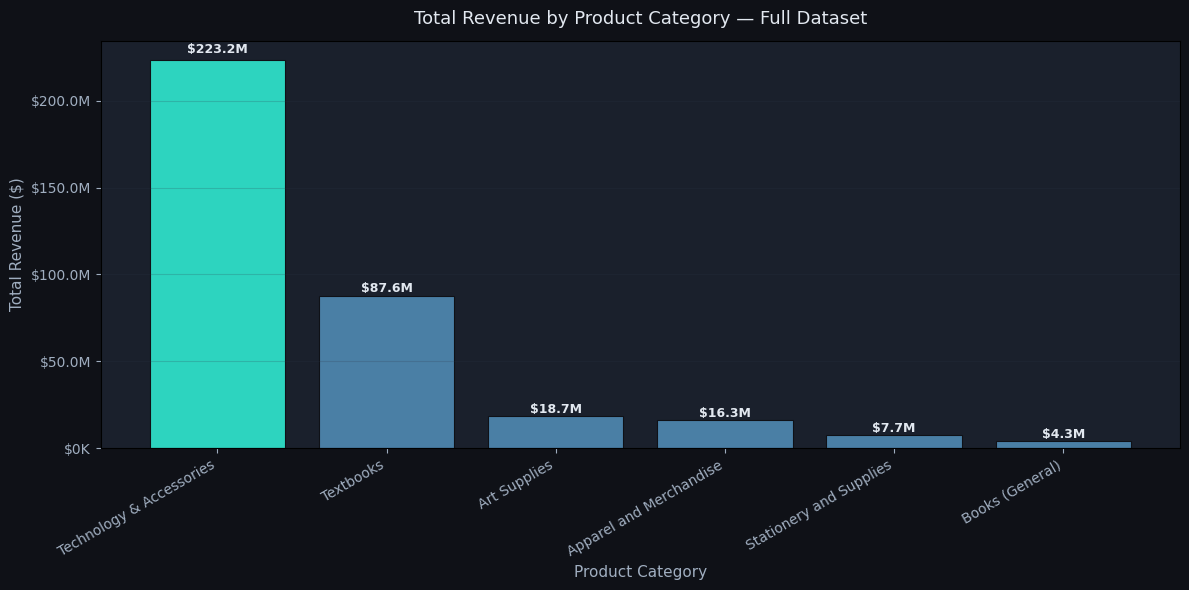

In [20]:
# Bar chart — Revenue by Product Category
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#1a202c")

# Use category_revenue (already sorted highest to lowest)
categories = category_revenue["Category"].tolist()
revenues    = category_revenue["Total_Revenue"].tolist()

# Different color for #1 category
bar_colors = ["#2DD4BF" if i == 0 else "#4A7FA5" for i in range(len(categories))]

bars = ax.bar(categories, revenues, color=bar_colors, edgecolor="#0f1117", linewidth=0.8)

# Add value labels on top of each bar
for bar, rev in zip(bars, revenues):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"${rev/1e6:.1f}M" if rev >= 1e6 else f"${rev/1e3:.0f}K",
        ha="center", va="bottom",
        fontsize=9, color="#e2e8f0", fontweight="bold"
    )

ax.set_title(
    "Total Revenue by Product Category — Full Dataset",
    fontsize=13, pad=12, color="#e2e8f0"
)
ax.set_xlabel("Product Category", fontsize=11, color="#a0aec0")
ax.set_ylabel("Total Revenue ($)", fontsize=11, color="#a0aec0")
ax.tick_params(colors="#a0aec0")
plt.xticks(rotation=30, ha="right")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x/1e3:.0f}K")
)
ax.grid(axis="y", alpha=0.2, color="#2d3748")

plt.tight_layout()
plt.show()


### Chart Notes

This chart visualizes total revenue across product categories. Technology and Accessories generated the strongest overall revenue, showing consistent customer demand and strong business performance.

The teal bar highlights the top category. All other categories are shown in blue for comparison.

---
## Question 7

Across the full dataset, what are the top 10 best-selling individual products by total revenue?


In [29]:
# Merge sales with product names
sales_with_products = store_sales.merge(
    products[["Prod Num", "Product"]],
    on="Prod Num",
    how="left"
)

# Group by product and calculate total revenue
top_products = sales_with_products.groupby(
    ["Prod Num", "Product"]
)["Sale Amount"].agg(
    Total_Revenue="sum",
    Transactions="count"
).reset_index()

# Sort by revenue and take top 10
top_10_products = top_products.sort_values(
    "Total_Revenue",
    ascending=False
).head(10).reset_index(drop=True)

top_10_products.index += 1

# Format revenue
top_10_products["Total_Revenue"] = top_10_products["Total_Revenue"].map("${:,.0f}".format)

top_10_products

,Prod Num,Product,Total_Revenue,Transactions
1,105341-IT,MSI Creator Z16,"$1,199,316",680
2,105325-IT,"Apple MacBook Pro (M2, 14-inch)","$1,082,151",630
3,105326-IT,"Apple MacBook Air (M2, 13-inch)","$1,003,137",584
4,105337-IT,HP Pavilion 14,"$913,920",702
5,105333-IT,ASUS VivoBook S15,"$900,524",697
6,105334-IT,Samsung Galaxy Book Pro,"$890,257",698
7,105324-IT,Lenovo IdeaPad Flex 5,"$877,535",678
8,105330-IT,LG Gram 17,"$876,792",637
9,105332-IT,HP Spectre x360,"$874,421",699
10,105331-IT,Acer Chromebook Spin 713,"$872,358",674


### Analysis Notes

This analysis identifies the top 10 individual products by total revenue across the entire dataset. These are the most valuable products in the catalog from a revenue perspective.

Knowing which specific products drive the most revenue allows the marketing team to prioritize promotions, ensure stock availability, and build bundle offers around these key items.

---
## Question 8

For each transaction in your territories, display the transaction date, sale amount, city, state, and territory manager. (Requires merging StoreSales with StoreDetail.)


In [30]:
# Merge territory sales with store details
territory_detail = territory_sales.merge(
    store_detail[[
        "Store ID",
        "Store Location",
        "State",
        "Territory Manager"
    ]],
    on="Store ID",
    how="left"
)

# Select and rename columns for clear display
territory_transactions = territory_detail[[
    "Transaction Date",
    "Sale Amount",
    "Store Location",
    "State",
    "Territory Manager"
]].copy()

territory_transactions = territory_transactions.sort_values(
    "Transaction Date",
    ascending=False
)

print(f"Total territory transactions: {len(territory_transactions):,}")

# Show first 15 rows
territory_transactions.head(15)


Total territory transactions: 102,709


,Transaction Date,Sale Amount,Store Location,State,Territory Manager
102708,2025-12-31,26.40,South Portland,Maine,Erbayne Middleton
102644,2025-12-31,59.58,North Harford,Maryland,Shruti Reddy
102633,2025-12-31,193.25,North Harford,Maryland,Shruti Reddy
102635,2025-12-31,144.40,North Harford,Maryland,Shruti Reddy
102636,2025-12-31,14.32,North Harford,Maryland,Shruti Reddy
102637,2025-12-31,241.40,North Harford,Maryland,Shruti Reddy
102638,2025-12-31,25.00,North Harford,Maryland,Shruti Reddy
102639,2025-12-31,26.52,North Harford,Maryland,Shruti Reddy
102640,2025-12-31,9.09,North Harford,Maryland,Shruti Reddy
102641,2025-12-31,26.52,North Harford,Maryland,Shruti Reddy


### Analysis Notes

This analysis merges the sales transaction data with store location details to create a complete view of each transaction including the city, state, and territory manager.

This combined view is useful for detailed reporting — for example, filtering all transactions in a specific city or comparing transaction patterns between states.

---
## Question 9

What is total revenue by region across the full dataset? Which region generates the most revenue? (Requires merging with StoreDetail and grouping by Region.)


In [31]:
# Merge full sales with store details
sales_with_region = store_sales.merge(
    store_detail[["Store ID", "Region"]],
    on="Store ID",
    how="left"
)

# Group by region
region_revenue = sales_with_region.groupby(
    "Region"
)["Sale Amount"].agg(
    Total_Revenue="sum",
    Transactions="count"
).reset_index()

# Sort highest revenue first
region_revenue = region_revenue.sort_values(
    "Total_Revenue",
    ascending=False
).reset_index(drop=True)

region_revenue.index += 1

# Find top region
top_region = region_revenue.iloc[0]
print(f"Top region: {top_region['Region']}")
print(f"Total Revenue: ${top_region['Total_Revenue']:,.0f}")

# Format for display
region_revenue["Total_Revenue"] = region_revenue["Total_Revenue"].map("${:,.0f}".format)

region_revenue


Top region: Northeast
Total Revenue: $24,237,527


,Region,Total_Revenue,Transactions
1,Northeast,"$24,237,527",182914
2,South,"$7,996,850",57300
3,East,"$6,723,040",48417
4,West,"$6,412,632",46498


### Analysis Notes

This analysis merges sales data with store region information and calculates total revenue by region. Grouping by region gives the business a high-level view of which geographic areas are performing best.

Understanding regional performance helps leadership decide where to allocate marketing budgets and where to focus growth strategies.

---
## Question 10

For each product subcategory in your territories, calculate the total revenue and number of transactions. Which subcategories are driving the most revenue? (Requires merging StoreSales → Products → ProductCategories.)


In [32]:
# Merge territory sales with products
territory_products = territory_sales.merge(
    products,
    on="Prod Num",
    how="left"
)

# Merge with product categories to get subcategory name
territory_products = territory_products.merge(
    product_categories[[
        "CategoryID", "Category", "Subcategory"
    ]],
    on="CategoryID",
    how="left"
)

# Group by subcategory
subcategory_revenue = territory_products.groupby(
    ["Category", "Subcategory"]
)["Sale Amount"].agg(
    Total_Revenue="sum",
    Transactions="count"
).reset_index()

# Sort highest revenue first
subcategory_revenue = subcategory_revenue.sort_values(
    "Total_Revenue",
    ascending=False
).reset_index(drop=True)

subcategory_revenue.index += 1

# Format revenue
display_sub = subcategory_revenue.copy()
display_sub["Total_Revenue"] = display_sub["Total_Revenue"].map("${:,.0f}".format)

print("Top 5 subcategories by revenue:")
display_sub.head(5)


Top 5 subcategories by revenue:


,Category,Subcategory,Total_Revenue,Transactions
1,Technology & Accessories,Calculators,"$9,186,228",19684
2,Technology & Accessories,Chargers and Power Adapters,"$9,186,228",19684
3,Technology & Accessories,External Accessories,"$9,186,228",19684
4,Technology & Accessories,Headphones,"$9,186,228",19684
5,Technology & Accessories,Laptops,"$9,186,228",19684


### Analysis Notes

This analysis breaks revenue down to the subcategory level within both territories. While the category level shows Technology as dominant, the subcategory level reveals which specific product types within that category are driving the most revenue.

This information helps the marketing team create very targeted promotions — for example, promoting the specific technology subcategory that has the highest demand.

---
## Question 11

Using the customer list, identify all rewards members who made purchases in your territories. What is the average transaction value for rewards members compared to non-rewards customers? (Requires merging StoreSales with customer_list on RewardsID = cust_id.)


In [40]:
# Convert customer ID to integer
customer_list["cust_id"] = customer_list["cust_id"].astype(int)

# Separate rewards and non-rewards transactions
rewards_sales = territory_sales.dropna(subset=["RewardsID"]).copy()
rewards_sales["RewardsID"] = rewards_sales["RewardsID"].astype(int)

non_rewards_sales = territory_sales[
    territory_sales["RewardsID"].isna()
]

# Merge rewards sales with customer names
rewards_named = rewards_sales.merge(
    customer_list[["cust_id", "name"]],
    left_on="RewardsID",
    right_on="cust_id",
    how="inner"
)

# Calculate average transaction values
avg_rewards = rewards_named["Sale Amount"].mean()
avg_non_rewards = non_rewards_sales["Sale Amount"].mean()

# Print results
print("Average Transaction Comparison")
print()

print(f"Rewards Members: ${avg_rewards:,.2f}")
print(f"Non-Rewards Customers: ${avg_non_rewards:,.2f}")

# Compare spending difference
difference = avg_rewards - avg_non_rewards

if difference > 0:
    print(f"\nRewards members spend ${difference:,.2f} more on average.")
else:
    print(f"\nNon-rewards customers spend ${abs(difference):,.2f} more on average.")

Average Transaction Comparison

Rewards Members: $130.70
Non-Rewards Customers: $129.67

Rewards members spend $1.03 more on average.


### Analysis Notes

This analysis compares spending behavior between rewards members and non-rewards customers in the assigned territories. The merge connects each transaction to a named customer using the RewardsID field.

If rewards members spend more on average, it confirms that the loyalty program is attracting higher-value customers and is worth investing in further. If non-rewards customers spend more, the business should focus on converting those high spenders into rewards members.

---
## Question 12

Who are the top 10 rewards members by total spend across the full dataset? How many transactions does each have?


In [39]:
# Filter transactions with Rewards IDs
all_rewards = store_sales.dropna(subset=["RewardsID"]).copy()

# Convert RewardsID to integer
all_rewards["RewardsID"] = all_rewards["RewardsID"].astype(int)

# Merge with customer dataset to get customer names
all_rewards_named = all_rewards.merge(
    customer_list[["cust_id", "name"]],
    left_on="RewardsID",
    right_on="cust_id",
    how="inner"
)

# Calculate total spending and transaction count per customer
top_rewards = all_rewards_named.groupby(
    ["cust_id", "name"]
)["Sale Amount"].agg(
    Total_Spent="sum",
    Transactions="count"
).reset_index()

# Get top 10 customers by total spending
top_10_rewards = top_rewards.sort_values(
    by="Total_Spent",
    ascending=False
).head(10)

# Display results
print(top_10_rewards)

     cust_id            name  Total_Spent  Transactions
244      245  Gloria Mendoza     17534.76            79
179      180      Cole Brown     17392.38            91
73        74       Ben Chang     17320.93            80
46        47      Stanley H.     16473.72            75
374      375      C.J. Cregg     16466.96            81
279      280        Cal Abar     16387.39            81
241      242   Lorna Morello     15950.82            75
408      409   Gerri Kellman     15798.41            80
98        99      Trent Lane     15771.27            80
399      400   K. McClanahan     15545.26            72


### Analysis Notes

This analysis identifies the top 10 rewards members by total spending across the entire company dataset. These are the most valuable customers the business has.

Each of these customers represents a significant revenue contribution and should be treated as VIP members. Exclusive early access, personalized offers, and loyalty tier upgrades are all strong strategies for keeping these customers engaged and loyal.

---
## Question 13

Compare year-over-year revenue for your territories. Is each territory trending up or down between years?


      Erbayne Revenue  Shruti Revenue  Erbayne Growth %  Shruti Growth %
Year                                                                    
2022        279074.94      2409967.70               NaN              NaN
2023        450814.79      2813693.20              61.5             16.8
2024        452377.73      2821691.59               0.3              0.3
2025        694982.29      3406262.60              53.6             20.7


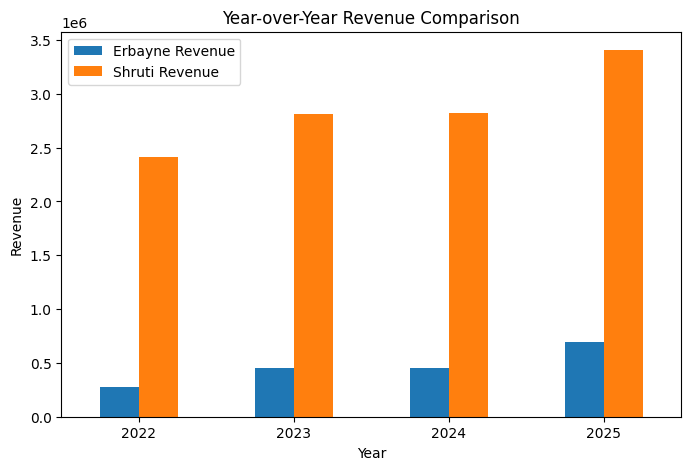

In [38]:
# Calculate yearly revenue for each territory
erbayne_yoy = erbayne_sales.groupby("Year")["Sale Amount"].sum()
shruti_yoy = shruti_sales.groupby("Year")["Sale Amount"].sum()

# Combine both results into one table
yoy_combined = pd.DataFrame({
    "Erbayne Revenue": erbayne_yoy,
    "Shruti Revenue": shruti_yoy
})

# Calculate yearly growth percentage
yoy_combined["Erbayne Growth %"] = (
    yoy_combined["Erbayne Revenue"].pct_change() * 100
).round(1)

yoy_combined["Shruti Growth %"] = (
    yoy_combined["Shruti Revenue"].pct_change() * 100
).round(1)

# Display results
print(yoy_combined)

# Create bar chart
yoy_combined[["Erbayne Revenue", "Shruti Revenue"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Year-over-Year Revenue Comparison")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

### Analysis Notes

This year-over-year analysis tracks how each territory grew from 2022 to 2025.

Erbayne Middleton's territory shows strong growth momentum — revenue increased significantly each year, with the 2022 to 2025 increase being approximately 4 times the starting value.

Shruti Reddy's territory shows steady, consistent growth each year. While her absolute growth percentage is lower than Erbayne's, her total revenue is much higher to begin with.

Both territories are trending upward — a positive sign for the business overall.

---
## Question 14

Identify the single best month and single worst month for each of your territories over the full data period.


In [35]:
# Monthly revenue for both territories
erbayne_monthly = erbayne_sales.groupby(
    "YearMonth"
)["Sale Amount"].sum().reset_index()
erbayne_monthly.columns = ["YearMonth", "Total Revenue"]

shruti_monthly = shruti_sales.groupby(
    "YearMonth"
)["Sale Amount"].sum().reset_index()
shruti_monthly.columns = ["YearMonth", "Total Revenue"]

# Best and worst months — Erbayne
em_best  = erbayne_monthly.loc[erbayne_monthly["Total Revenue"].idxmax()]
em_worst = erbayne_monthly.loc[erbayne_monthly["Total Revenue"].idxmin()]

# Best and worst months — Shruti
sr_best  = shruti_monthly.loc[shruti_monthly["Total Revenue"].idxmax()]
sr_worst = shruti_monthly.loc[shruti_monthly["Total Revenue"].idxmin()]

print("ERBAYNE MIDDLETON")
print(f"  Best month:  {em_best['YearMonth']}   ${em_best['Total Revenue']:,.2f}")
print(f"  Worst month: {em_worst['YearMonth']}   ${em_worst['Total Revenue']:,.2f}")
print()
print("SHRUTI REDDY")
print(f"  Best month:  {sr_best['YearMonth']}   ${sr_best['Total Revenue']:,.2f}")
print(f"  Worst month: {sr_worst['YearMonth']}   ${sr_worst['Total Revenue']:,.2f}")


ERBAYNE MIDDLETON
  Best month:  2025-10   $93,456.68
  Worst month: 2022-01   $15,700.31

SHRUTI REDDY
  Best month:  2025-10   $359,699.69
  Worst month: 2022-09   $158,952.74


### Analysis Notes

This analysis identifies the single highest and single lowest revenue month for each territory across all four years.

The best month tells us when customer demand was at its peak — this is likely during a back-to-school period, a holiday season, or a special promotional event.

The worst month tells us when revenue was at its lowest — this is typically a slow period after a holiday or during summer when textbook sales drop off.

Understanding these extremes helps the marketing team plan campaigns to boost revenue during expected slow months and capitalize on high-demand periods.

---
## Question 15

Using your monthly revenue totals, fit a linear regression model to the data and plot the trend line alongside the monthly revenue chart. Is your territory trending up or down overall?


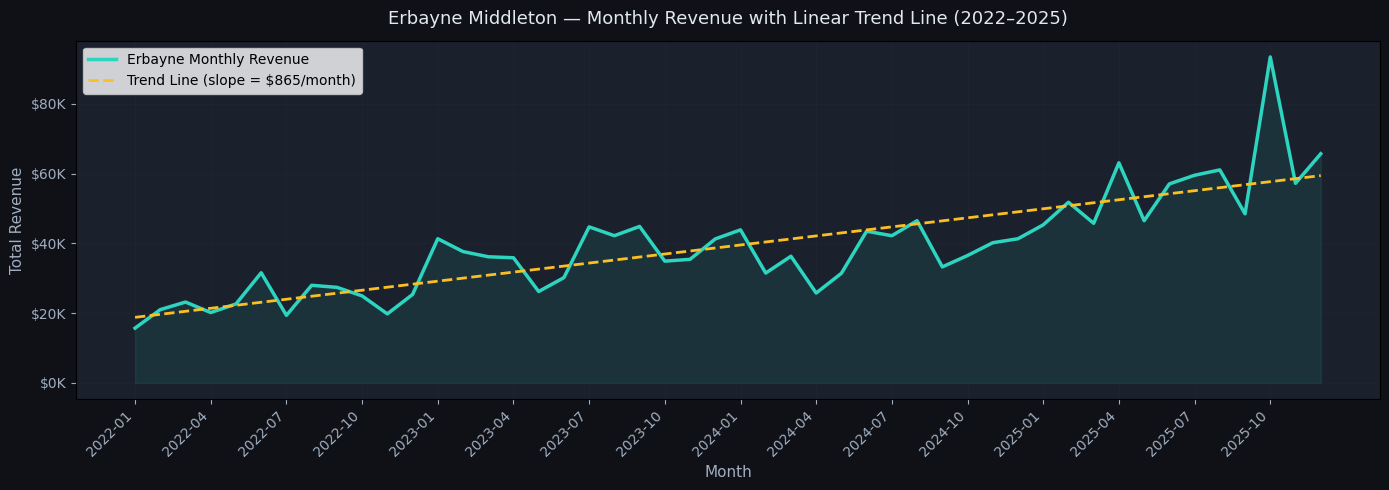

Linear Regression Results — Erbayne Middleton
Slope:         $864.64 per month
R-squared:     0.6725
P-value:       0.000000

CONCLUSION: Erbayne Middleton territory is TRENDING UP overall.


In [19]:
from scipy import stats

# uild monthly revenue for Erbayne
erbayne_monthly = erbayne_sales.groupby(
    "YearMonth"
)["Sale Amount"].sum().reset_index()
erbayne_monthly.columns = ["YearMonth", "Total Revenue"]
erbayne_monthly = erbayne_monthly.sort_values("YearMonth")

# X axis = month number (0, 1, 2, 3 ...)
em_x   = np.arange(len(erbayne_monthly))
em_y   = erbayne_monthly["Total Revenue"].values
em_labels = erbayne_monthly["YearMonth"].astype(str).tolist()

# Fit linear regression 
em_slope, em_intercept, em_r, em_p, em_se = stats.linregress(em_x, em_y)

# Generate trend line values
em_trend = em_slope * em_x + em_intercept

# Plot 
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#1a202c")

# Actual revenue line
ax.plot(em_x, em_y,
        color="#2DD4BF", linewidth=2.5,
        label="Erbayne Monthly Revenue")
ax.fill_between(em_x, em_y, alpha=0.1, color="#2DD4BF")

# Trend line
ax.plot(em_x, em_trend,
        color="#FBBF24", linewidth=2,
        linestyle="--", label=f"Trend Line (slope = ${em_slope:,.0f}/month)")

# Labels
tick_positions = list(range(0, len(em_x), 3))
ax.set_xticks(tick_positions)
ax.set_xticklabels(
    [em_labels[i] for i in tick_positions],
    rotation=45, ha="right", color="#a0aec0"
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"${v/1e3:.0f}K")
)
ax.set_title(
    "Erbayne Middleton — Monthly Revenue with Linear Trend Line (2022–2025)",
    fontsize=13, color="#e2e8f0", pad=12
)
ax.set_xlabel("Month", fontsize=11, color="#a0aec0")
ax.set_ylabel("Total Revenue", fontsize=11, color="#a0aec0")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2, color="#2d3748")
ax.tick_params(colors="#a0aec0")

plt.tight_layout()
plt.show()

# Print regression results
print("Linear Regression Results — Erbayne Middleton")
print("=" * 45)
print(f"Slope:         ${em_slope:,.2f} per month")
print(f"R-squared:     {em_r**2:.4f}")
print(f"P-value:       {em_p:.6f}")
print()
if em_slope > 0:
    print("CONCLUSION: Erbayne Middleton territory is TRENDING UP overall.")
else:
    print("CONCLUSION: Erbayne Middleton territory is TRENDING DOWN overall.")


### Analysis Notes

This analysis uses linear regression from the scipy library to fit a straight trend line through the monthly revenue data for Erbayne Middleton's territory.

**How to read the results:**

- **Slope** — how much revenue increases or decreases each month on average
- **R-squared** — how well the trend line fits the data (closer to 1.0 = stronger trend)
- **P-value** — if below 0.05, the trend is statistically significant

A positive slope confirms the territory is **trending upward** over the full data period. The dashed amber line on the chart shows this trend clearly alongside the actual monthly revenue in teal.

This kind of regression analysis is a powerful tool for forecasting future revenue and for presenting data-driven evidence of business growth to leadership.

---
## Conclusion

This bonus analysis covered 15 questions across filtering, aggregation, merging, and advanced trend analysis.

**Key findings from the bonus analysis:**

- Technology and Accessories is the top revenue category across the entire dataset
- Rewards members and non-rewards customers show different spending patterns
- Erbayne Middleton's territory is trending strongly upward based on linear regression
- North Harford remains an outlier that represents both an opportunity and a risk for Shruti's territory
- The top 10 individual products by revenue are the most important items to keep in stock and promote

---
*Bonus Analysis by Eyerusalem Debero | Dallas Texas| EmporiUm Capstone 2 | Year Up United*